# NBA Salary Prediction Baseline

This notebook builds two baseline models for predicting player salary in the 2025-2026 NBA season. It uses `nba_salary_2025_26.csv` and trains on `log1p(Salary_M)`, then reports performance in the original `Salary_M` scale using RMSE, MAE, and R².

## 1. Setup and imports

Load the packages needed for data processing, modeling, and evaluation.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")

## 2. Load and inspect the dataset

Read `nba_salary_2025_26.csv`, inspect dimensions, and confirm the target column.

In [3]:
data_path = "nba_salary_2025_26.csv"
df = pd.read_csv(data_path)
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing values by column:")
print(df.isna().sum()[df.isna().sum() > 0])
df.head()

Dataset shape: (438, 29)
Columns: ['Player', 'Pos', 'Age', 'Tm', 'G', 'MP', 'PER', 'TS%', 'USG%', 'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'GS', 'PTS', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'FG%', '3P%', 'FT%', 'Salary', 'Salary_M']
Missing values by column:
3P%    15
dtype: int64


,Player,Pos,Age,Tm,G,MP,PER,TS%,USG%,OWS,...,TRB,AST,STL,BLK,TOV,FG%,3P%,FT%,Salary,Salary_M
0,Amen Thompson,PG,23.0,HOU,75.0,2795.0,18.6,0.587,19.9,5.9,...,7.8,5.3,1.5,0.6,2.4,0.525,0.223,0.780,9690600.0,9.690600
1,Kevin Durant,SF,37.0,HOU,74.0,2690.0,21.0,0.638,27.1,6.8,...,5.4,4.7,0.8,0.9,3.2,0.518,0.409,0.877,54708609.0,54.708609
2,Desmond Bane,SG,27.0,ORL,77.0,2625.0,16.9,0.609,23.3,4.7,...,4.2,4.2,1.0,0.4,2.0,0.485,0.391,0.920,36725670.0,36.725670
3,Mikal Bridges,SF,29.0,NYK,78.0,2596.0,15.2,0.584,17.4,4.5,...,3.9,3.8,1.3,0.8,1.1,0.487,0.371,0.832,24900000.0,24.900000
4,Toumani Camara,PF,25.0,POR,78.0,2590.0,11.2,0.576,16.2,1.8,...,5.2,2.4,1.1,0.4,1.8,0.439,0.366,0.704,2221677.0,2.221677


## 3. Preprocessing

Define the transformed target and model features. Keep preprocessing simple for the baseline.

In [4]:
df = df.copy()
df = df.dropna(subset=["Salary_M"]).copy()
df["3P%"] = df["3P%"].fillna(0.0)
df["Salary_M"] = pd.to_numeric(df["Salary_M"], errors="coerce")
df = df.dropna(subset=["Salary_M"]).copy()
df["log_salary_m"] = np.log1p(df["Salary_M"]).astype(float)

numeric_features = [
    "Age", "G", "MP", "PER", "TS%", "USG%", "OWS", "DWS",
    "WS", "WS/48", "OBPM", "DBPM", "BPM", "VORP", "GS", "PTS", "TRB", "AST",
    "STL", "BLK", "TOV", "FG%", "3P%", "FT%"
]
available_features = [c for c in numeric_features if c in df.columns]
df_features = df[available_features + ["Pos"]].copy()
df_features = pd.get_dummies(df_features, columns=["Pos"], drop_first=True)
feature_columns = df_features.columns.tolist()

df_model = pd.concat([df[[]], df_features], axis=1)
df_model["log_salary_m"] = df["log_salary_m"]

df_model = df_model.dropna().copy()

print("Model dataset shape after preprocessing:", df_model.shape)
print("Feature count:", len(feature_columns))
feature_columns[:20]

Model dataset shape after preprocessing: (438, 29)
Feature count: 28


['Age',
 'G',
 'MP',
 'PER',
 'TS%',
 'USG%',
 'OWS',
 'DWS',
 'WS',
 'WS/48',
 'OBPM',
 'DBPM',
 'BPM',
 'VORP',
 'GS',
 'PTS',
 'TRB',
 'AST',
 'STL',
 'BLK']

## 4. Train/test split

Split into train and test sets before building baselines.

In [5]:
X = df_model[feature_columns].values
y = df_model["log_salary_m"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaled feature shape:", X_train_scaled.shape)

Training samples: 328
Test samples: 110
Scaled feature shape: (328, 28)


## 5. Baseline 1: Median predictor

Use the training median of the transformed target as a constant prediction for every player.

In [6]:
median_value = np.median(y_train)
y_pred_median = np.full_like(y_test, fill_value=median_value)

def evaluate(y_true, y_pred_transformed):
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred_transformed)
    rmse = mean_squared_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(rmse)
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    r2 = r2_score(y_true_orig, y_pred_orig)
    return rmse, mae, r2

median_rmse, median_mae, median_r2 = evaluate(y_test, y_pred_median)
print("Median baseline results (Salary_M scale):")
print("RMSE:", round(median_rmse, 3), "million")
print("MAE:", round(median_mae, 3), "million")
print("R²:", round(median_r2, 3))

Median baseline results (Salary_M scale):
RMSE: 14.735 million
MAE: 9.577 million
R²: -0.208


## 6. Baseline 2: Linear regression

Train a linear regression model on the log-transformed target and evaluate on the original salary scale.

In [7]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
lr_rmse, lr_mae, lr_r2 = evaluate(y_test, y_pred_lr)
print("Linear regression baseline results (Salary_M scale):")
print("RMSE:", round(lr_rmse, 3), "million")
print("MAE:", round(lr_mae, 3), "million")
print("R²:", round(lr_r2, 3))

Linear regression baseline results (Salary_M scale):
RMSE: 9.41 million
MAE: 6.041 million
R²: 0.507


## 6b. Ridge Regression

Ridge adds L2 regularization to handle multicollinearity between WS, VORP, and BPM.
We test several alpha values and pick the best one.

In [8]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
best_alpha = None
best_r2 = -np.inf

print("Ridge Regression — alpha search")
print("-" * 45)

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    rmse, mae, r2 = evaluate(y_test, y_pred)
    print(f"  alpha={a:<6}  RMSE={rmse:.3f}M   MAE={mae:.3f}M   R²={r2:.3f}")
    if r2 > best_r2:
        best_r2 = r2
        best_alpha = a

print(f"\nBest alpha: {best_alpha}")
ridge_final = Ridge(alpha=best_alpha)
ridge_final.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_final.predict(X_test_scaled)
ridge_rmse, ridge_mae, ridge_r2 = evaluate(y_test, y_pred_ridge)

print(f"\nRidge Regression final results (Salary_M scale):")
print(f"  RMSE: {ridge_rmse:.3f} million")
print(f"  MAE:  {ridge_mae:.3f} million")
print(f"  R²:   {ridge_r2:.3f}")

Ridge Regression — alpha search
---------------------------------------------
  alpha=0.01    RMSE=9.400M   MAE=6.042M   R²=0.509
  alpha=0.1     RMSE=9.375M   MAE=6.047M   R²=0.511
  alpha=1.0     RMSE=9.425M   MAE=6.086M   R²=0.506
  alpha=10.0    RMSE=9.510M   MAE=6.174M   R²=0.497
  alpha=100.0   RMSE=9.290M   MAE=6.314M   R²=0.520

Best alpha: 100.0

Ridge Regression final results (Salary_M scale):
  RMSE: 9.290 million
  MAE:  6.314 million
  R²:   0.520


## 7. Results and plots

Compare all three models with individual and combined visualizations of actual vs predicted and residuals.

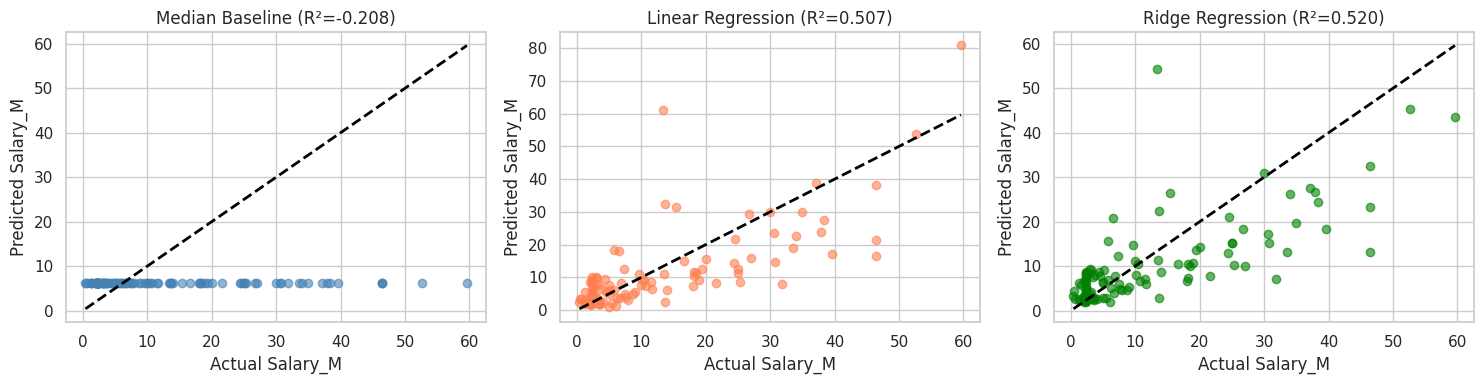

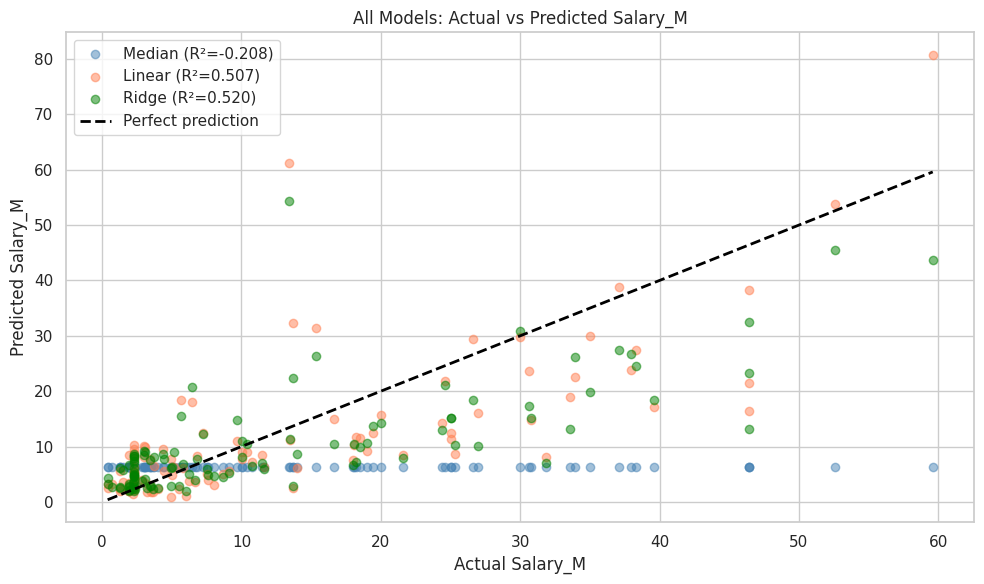

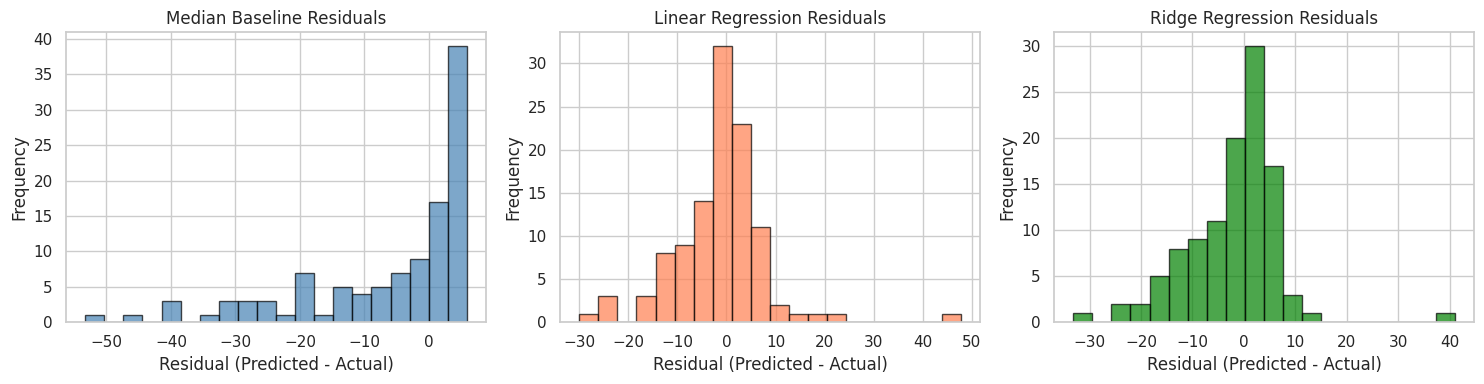

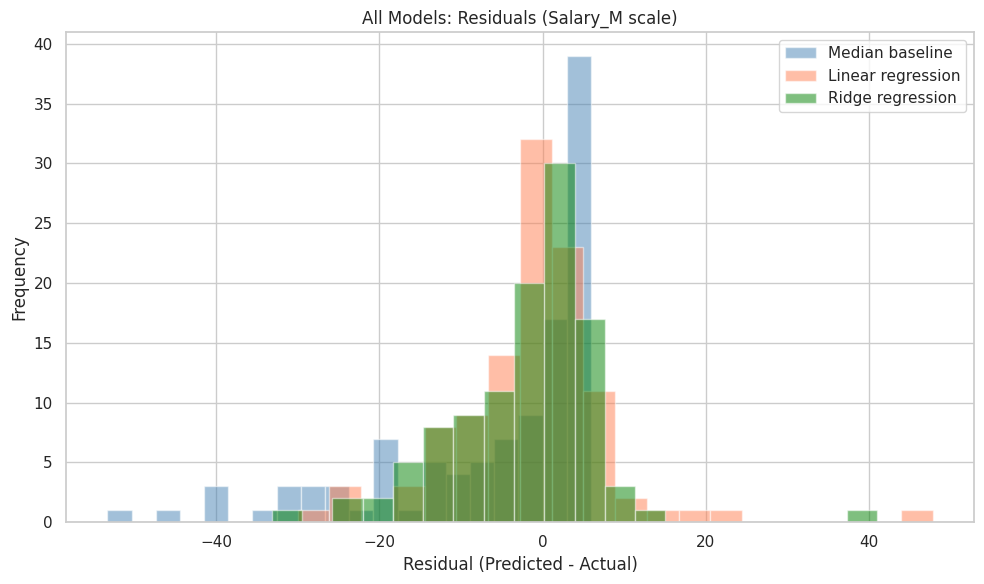

In [10]:
y_test_orig = np.expm1(y_test)
median_pred_orig = np.expm1(y_pred_median)
lr_pred_orig = np.expm1(y_pred_lr)
ridge_pred_orig = np.expm1(y_pred_ridge)

# Calculate residuals
residuals_median = median_pred_orig - y_test_orig
residuals_lr = lr_pred_orig - y_test_orig
residuals_ridge = ridge_pred_orig - y_test_orig

# ===== ACTUAL VS PREDICTED: INDIVIDUAL PLOTS =====
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_test_orig, median_pred_orig, alpha=0.6, color='steelblue')
axes[0].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 
             color="black", linestyle="--", linewidth=2)
axes[0].set_xlabel("Actual Salary_M")
axes[0].set_ylabel("Predicted Salary_M")
axes[0].set_title(f"Median Baseline (R²={median_r2:.3f})")

axes[1].scatter(y_test_orig, lr_pred_orig, alpha=0.6, color='coral')
axes[1].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 
             color="black", linestyle="--", linewidth=2)
axes[1].set_xlabel("Actual Salary_M")
axes[1].set_ylabel("Predicted Salary_M")
axes[1].set_title(f"Linear Regression (R²={lr_r2:.3f})")

axes[2].scatter(y_test_orig, ridge_pred_orig, alpha=0.6, color='green')
axes[2].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 
             color="black", linestyle="--", linewidth=2)
axes[2].set_xlabel("Actual Salary_M")
axes[2].set_ylabel("Predicted Salary_M")
axes[2].set_title(f"Ridge Regression (R²={ridge_r2:.3f})")

plt.tight_layout()
plt.show()

# ===== ACTUAL VS PREDICTED: COMBINED PLOT =====
plt.figure(figsize=(10, 6))
plt.scatter(y_test_orig, median_pred_orig, alpha=0.5, label=f"Median (R²={median_r2:.3f})", color='steelblue')
plt.scatter(y_test_orig, lr_pred_orig, alpha=0.5, label=f"Linear (R²={lr_r2:.3f})", color='coral')
plt.scatter(y_test_orig, ridge_pred_orig, alpha=0.5, label=f"Ridge (R²={ridge_r2:.3f})", color='green')
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 
         color="black", linestyle="--", linewidth=2, label="Perfect prediction")
plt.xlabel("Actual Salary_M")
plt.ylabel("Predicted Salary_M")
plt.title("All Models: Actual vs Predicted Salary_M")
plt.legend()
plt.tight_layout()
plt.show()

# ===== RESIDUALS: INDIVIDUAL PLOTS =====
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(residuals_median, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_title("Median Baseline Residuals")
axes[0].set_xlabel("Residual (Predicted - Actual)")
axes[0].set_ylabel("Frequency")

axes[1].hist(residuals_lr, bins=20, alpha=0.7, color='coral', edgecolor='black')
axes[1].set_title("Linear Regression Residuals")
axes[1].set_xlabel("Residual (Predicted - Actual)")
axes[1].set_ylabel("Frequency")

axes[2].hist(residuals_ridge, bins=20, alpha=0.7, color='green', edgecolor='black')
axes[2].set_title("Ridge Regression Residuals")
axes[2].set_xlabel("Residual (Predicted - Actual)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# ===== RESIDUALS: COMBINED PLOT =====
plt.figure(figsize=(10, 6))
plt.hist(residuals_median, bins=20, alpha=0.5, label="Median baseline", color='steelblue')
plt.hist(residuals_lr, bins=20, alpha=0.5, label="Linear regression", color='coral')
plt.hist(residuals_ridge, bins=20, alpha=0.5, label="Ridge regression", color='green')
plt.xlabel("Residual (Predicted - Actual)")
plt.ylabel("Frequency")
plt.title("All Models: Residuals (Salary_M scale)")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusion

The notebook implements two baselines for NBA salary prediction using `Salary_M` as the real-world target and `log1p(Salary_M)` for modeling. The median baseline provides a simple constant benchmark, while the linear regression baseline demonstrates whether a small set of player performance statistics can explain salary variance.